# Error Analysis

LLM-categorised root-cause analysis of False Positive / False Negative errors, for entities and relations, on a single dataset split. Reads directly from the final pipeline's `<split>_predictions.json` (`errors` field).

FP/FN lists are downsampled to `SAMPLE_SIZE` per bucket (entity-FP, entity-FN, relation-FP, relation-FN) using the same seeded-random approach as the original notebook -- buckets already at or under `SAMPLE_SIZE` are used in full.

**Note:** the original notebook only ran LLM categorisation on relation errors. This version extends the same category set (`ERROR_CATEGORIES`) to entity errors too. Worth a quick sanity check that the category descriptions actually make sense for entity-level errors, not just relation-level ones, before trusting the entity results.

The categorisation logic itself now lives in `modules/error_categorisation.py` rather than as notebook-local functions.

In [1]:
import os
import json

import pandas as pd

from pathlib import Path
from openai import OpenAI

from modules.corpus import get_gt_dict
from modules.distribution_plotting import plot_error_type_distribution
from modules.error_categorisation import categorise_errors, load_cached_error_codes, category_df

from config.data_config import DATA_CONFIG
from config.error_config import ERROR_CATEGORIES

### Configuration

In [9]:
# ---------- Manual dataset split entry ----------
DATASET_SPLIT = "biored_test"
CALL_API = True
SAMPLE_SIZE = 50

OUTPUT_DIRECTORY = DATA_CONFIG[DATASET_SPLIT]["output_directory"]
PREDICTIONS_PATH = f"{OUTPUT_DIRECTORY}{DATASET_SPLIT}_predictions.json"

SAVE_PATH = f"{OUTPUT_DIRECTORY}error_codes"
os.makedirs(SAVE_PATH, exist_ok=True)

### Load Errors

In [10]:
with open(PREDICTIONS_PATH, "r") as f:
    predictions = json.load(f)

if "errors" not in predictions:
    raise ValueError(
        f"'{PREDICTIONS_PATH}' has no 'errors' field -- run the evaluation "
        f"cell in 01_final_pipeline.ipynb for '{DATASET_SPLIT}' first."
    )

errors = predictions["errors"]

for kind in ("entities", "relations"):
    n_fp = len(errors[kind]["false_positives"])
    n_fn = len(errors[kind]["false_negatives"])
    print(f"{kind:9s} -- FP: {n_fp}, FN: {n_fn}, total: {n_fp + n_fn}")

entities  -- FP: 109, FN: 413, total: 522
relations -- FP: 482, FN: 517, total: 999


### Load Ground Truths + Abstracts

Needed as context for the LLM categorisation prompts.

In [11]:
NER_GT_PATH = DATA_CONFIG[DATASET_SPLIT]["ground_truths"]["ner"]
RE_GT_PATH = DATA_CONFIG[DATASET_SPLIT]["ground_truths"]["re"]
ABSTRACTS_EVAL_PATH = DATA_CONFIG[DATASET_SPLIT]["abstracts"]["abstracts_eval"]

ner_gt = pd.read_csv(NER_GT_PATH)
re_gt = pd.read_csv(RE_GT_PATH)

abstracts_eval = pd.read_csv(ABSTRACTS_EVAL_PATH)
abstracts_eval.set_index("pmid", inplace=True)

gt_dict = get_gt_dict(ner_gt, re_gt, abstracts_eval)

print("Successfully loaded ground truths and abstracts.")

Successfully loaded ground truths and abstracts.


### API Client

In [12]:
client = OpenAI(
    api_key=os.getenv("OPEN_AI_KEY"),
    timeout=120,
    max_retries=2
)

### LLM Error Categorisation

Categorises a `SAMPLE_SIZE`-capped sample of FP/FN (entities and relations) into one of `ERROR_CATEGORIES`, using the source abstract and matching ground-truth items as context. Results are saved incrementally per item, so an interrupted run can be resumed by re-loading the partial file rather than starting over.

In [13]:
if CALL_API:
    print("Categorising entity errors...")
    entity_error_codes = categorise_errors(
        "entities", client, errors, gt_dict, abstracts_eval,
        ERROR_CATEGORIES, SAVE_PATH, DATASET_SPLIT, sample_size=SAMPLE_SIZE,
    )

    print("Categorising relation errors...")
    relation_error_codes = categorise_errors(
        "relations", client, errors, gt_dict, abstracts_eval,
        ERROR_CATEGORIES, SAVE_PATH, DATASET_SPLIT, sample_size=SAMPLE_SIZE,
    )

    print(f"Saved entity/relation error codes to '{SAVE_PATH}'")
else:
    entity_error_codes = load_cached_error_codes(SAVE_PATH, DATASET_SPLIT, "entities")
    relation_error_codes = load_cached_error_codes(SAVE_PATH, DATASET_SPLIT, "relations")

    print(f"Loaded cached entity/relation error codes from '{SAVE_PATH}'")

Categorising entity errors...
'entities' FP Sample Length: 50
'entities' FN Sample Length: 50
Categorising relation errors...
'relations' FP Sample Length: 50
'relations' FN Sample Length: 50
Saved entity/relation error codes to '../data/results/final/biored_test/error_codes'


### Plot Error Category Distribution

Diverging horizontal bars: False Positives on the left, False Negatives on the right, by LLM-assigned error category -- same greyscale/hatched styling used throughout `distribution_plotting.py`. Reuses `plot_error_type_distribution` directly, passing `category` as the grouping column instead of `type`/`relation`.

e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:246: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(x):.0f}%" for x in xticks])
e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:246: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(x):.0f}%" for x in xticks])


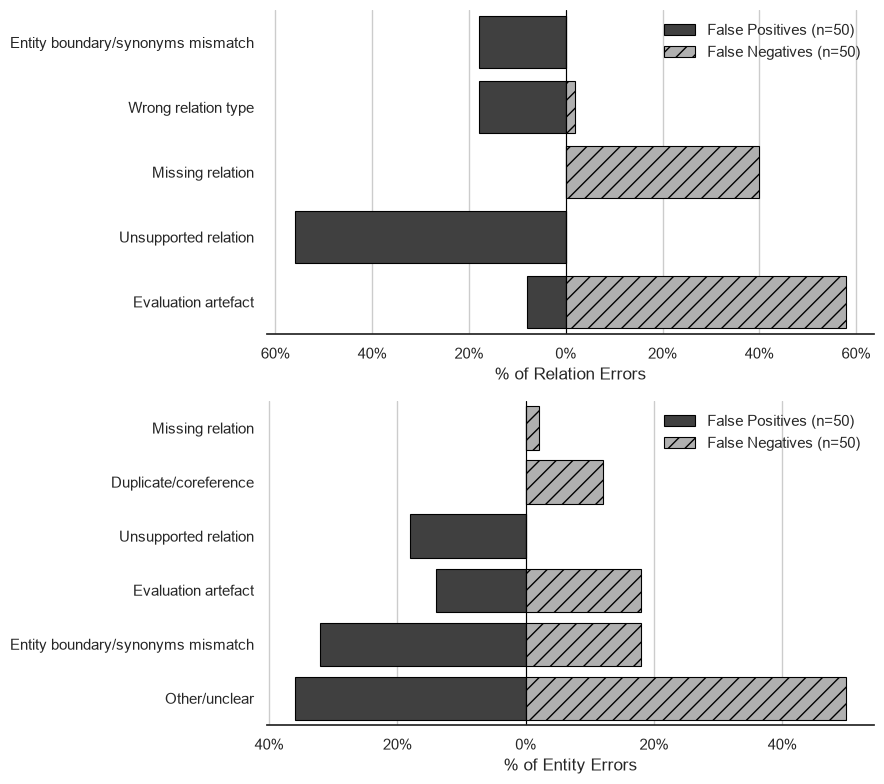

In [14]:
entity_fp_cat = category_df(entity_error_codes, "fp")
entity_fn_cat = category_df(entity_error_codes, "fn")
relation_fp_cat = category_df(relation_error_codes, "fp")
relation_fn_cat = category_df(relation_error_codes, "fn")

fig, axes = plot_error_type_distribution(
    entity_fp_cat, entity_fn_cat,
    relation_fp_cat, relation_fn_cat,
    entity_col="category", relation_col="category",
)

### Export Figure

In [15]:
FIGURE_DIR = Path(f"../img/error_analysis/{DATASET_SPLIT}")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(FIGURE_DIR / f"{DATASET_SPLIT}_error_category_distribution.png", dpi=150)
print(f"Saved '{DATASET_SPLIT}_error_category_distribution.png' to '{FIGURE_DIR}'")

Saved 'biored_test_error_category_distribution.png' to '..\img\error_analysis\biored_test'
